# Handwriting Style Identification
## IVP Mini Project — Writer Identification using Traditional Image Processing

**Approach:** Texture & Structural Feature Extraction using:
- Local Binary Patterns (LBP) — Texture descriptor
- Run-Length Features — Stroke pattern analysis
- Gradient Orientation Histogram (HOG-like, manually coded)
- Slant & Skew Analysis
- Writer Clustering via Cosine Similarity (pure math, no ML library)

> ⚠️ No AI / ML / DL / Neural Networks / Pretrained Models used. Pure OpenCV + NumPy + SciPy.

In [1]:
# ============================================================
# CELL 1: Install & Import Libraries
# Purpose: Install any missing packages and import everything needed
# ============================================================

# Install scikit-image for LBP (it's a traditional image processing library — NOT ML)
!pip install scikit-image --quiet

import os
import re
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from skimage.feature import local_binary_pattern
from collections import defaultdict
from sklearn.preprocessing import normalize  # Only for L2 norm — no ML used

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")
print("OpenCV version:", cv2.__version__)
print("NumPy version:", np.__version__)

✅ All libraries imported successfully!
OpenCV version: 4.13.0
NumPy version: 2.0.2


In [2]:
# ============================================================
# CELL 2: Mount Google Drive
# Purpose: Connect your Google Drive so we can access the dataset
# ============================================================

from google.colab import drive
drive.mount('/content/drive')
print("✅ Google Drive mounted successfully!")

Mounted at /content/drive
✅ Google Drive mounted successfully!


In [3]:
# ============================================================
# CELL 3: Dataset Path Setup & Validation
# Purpose: Point to your dataset folder and verify files exist
# ============================================================

# ── SET YOUR DATASET PATH HERE ──
DATASET_PATH = "/content/drive/MyDrive/data_subset"

# Verify path exists
if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(f"❌ Dataset folder not found at: {DATASET_PATH}\nPlease check your Google Drive path.")

# Collect all PNG images
all_images = [f for f in os.listdir(DATASET_PATH) if f.lower().endswith('.png')]
all_images.sort()

print(f"✅ Dataset found at: {DATASET_PATH}")
print(f"📁 Total PNG images found: {len(all_images)}")
print(f"\n📄 Sample filenames:")
for f in all_images[:5]:
    print(f"   {f}")

✅ Dataset found at: /content/drive/MyDrive/data_subset
📁 Total PNG images found: 4899

📄 Sample filenames:
   a01-000u-s00-00.png
   a01-000u-s00-01.png
   a01-000u-s00-02.png
   a01-000u-s00-03.png
   a01-000u-s01-00.png


In [4]:
# ============================================================
# CELL 4: Writer ID Extraction from Filename
# Purpose: Parse IAM filenames to extract writer IDs
#
# IAM Filename Format: WRITER-FORM-SENTENCE-LINE.png
# Example: m06-048-s00-01.png  → writer = 'm06'
#          n02-031-s08-00.png  → writer = 'n02'
# The first part before the first hyphen is the WRITER ID
# ============================================================

def extract_writer_id(filename):
    """
    Extract writer ID from IAM dataset filename.
    Format: WRITER-FORM-SENTENCE-LINE.png
    Returns the first segment as writer ID.
    """
    # Remove extension, split by hyphen, take first part
    name = os.path.splitext(filename)[0]
    parts = name.split('-')
    return parts[0]  # e.g., 'm06', 'n02', 'a01'

# Group images by writer
writer_dict = defaultdict(list)
for fname in all_images:
    wid = extract_writer_id(fname)
    writer_dict[wid].append(fname)

print(f"✅ Unique writers found: {len(writer_dict)}")
print(f"\n📊 Top 10 writers by sample count:")
sorted_writers = sorted(writer_dict.items(), key=lambda x: len(x[1]), reverse=True)
for wid, files in sorted_writers[:10]:
    print(f"   Writer '{wid}': {len(files)} images")

✅ Unique writers found: 25

📊 Top 10 writers by sample count:
   Writer 'g06': 1579 images
   Writer 'c03': 618 images
   Writer 'a01': 354 images
   Writer 'r06': 320 images
   Writer 'a05': 291 images
   Writer 'n06': 245 images
   Writer 'c06': 176 images
   Writer 'b06': 173 images
   Writer 'p06': 153 images
   Writer 'a02': 143 images


In [5]:
# ============================================================
# CELL 5: Select Writers for Identification
# Purpose: Pick writers that have enough images for reliable analysis
# We only pick writers with >= MIN_SAMPLES images
# ============================================================

MIN_SAMPLES   = 5    # Minimum images per writer for reliable features
MAX_WRITERS   = 15   # Analyze top N writers (increase if you want more)
MAX_PER_WRITER = 10  # Max images used per writer (for speed)

# Filter writers with enough samples
eligible = [(wid, files) for wid, files in sorted_writers if len(files) >= MIN_SAMPLES]
selected_writers = eligible[:MAX_WRITERS]

print(f"✅ Writers selected for analysis: {len(selected_writers)}")
print(f"\nSelected writers:")
for wid, files in selected_writers:
    used = min(len(files), MAX_PER_WRITER)
    print(f"   Writer '{wid}': {len(files)} images available, using {used}")

✅ Writers selected for analysis: 15

Selected writers:
   Writer 'g06': 1579 images available, using 10
   Writer 'c03': 618 images available, using 10
   Writer 'a01': 354 images available, using 10
   Writer 'r06': 320 images available, using 10
   Writer 'a05': 291 images available, using 10
   Writer 'n06': 245 images available, using 10
   Writer 'c06': 176 images available, using 10
   Writer 'b06': 173 images available, using 10
   Writer 'p06': 153 images available, using 10
   Writer 'a02': 143 images available, using 10
   Writer 'm06': 142 images available, using 10
   Writer 'j06': 139 images available, using 10
   Writer 'h06': 87 images available, using 10
   Writer 'd06': 86 images available, using 10
   Writer 'p03': 74 images available, using 10


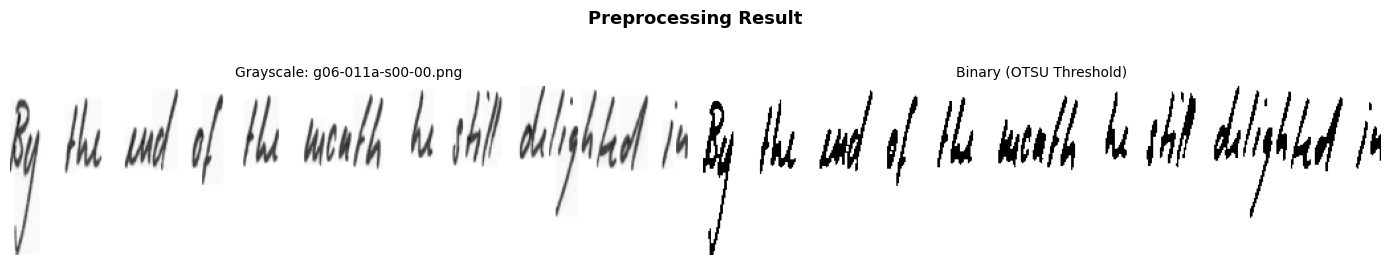

✅ Preprocessing working correctly!


In [6]:
# ============================================================
# CELL 6: Image Preprocessing
# Purpose: Load and clean each image before feature extraction
#
# Steps:
# 1. Load as grayscale
# 2. OTSU thresholding to binarize
# 3. Morphological noise removal
# 4. Resize to fixed size for uniform feature vectors
# ============================================================

TARGET_SIZE = (128, 512)  # Height x Width — landscape for handwriting lines

def preprocess_image(image_path):
    """
    Load and preprocess a handwriting image.
    Returns: grayscale image, binary image (both resized)
    """
    # Load grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None, None

    # Resize to standard size
    img_resized = cv2.resize(img, (TARGET_SIZE[1], TARGET_SIZE[0]),
                             interpolation=cv2.INTER_AREA)

    # OTSU thresholding: automatically finds best threshold
    _, binary = cv2.threshold(img_resized, 0, 255,
                              cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Morphological opening: removes small noise dots
    kernel = np.ones((2, 2), np.uint8)
    binary_clean = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

    return img_resized, binary_clean

# --- Quick Test ---
test_fname = selected_writers[0][1][0]
test_path  = os.path.join(DATASET_PATH, test_fname)
gray_test, bin_test = preprocess_image(test_path)

fig, axes = plt.subplots(1, 2, figsize=(14, 3))
axes[0].imshow(gray_test, cmap='gray')
axes[0].set_title(f"Grayscale: {test_fname}", fontsize=10)
axes[0].axis('off')
axes[1].imshow(bin_test, cmap='gray')
axes[1].set_title("Binary (OTSU Threshold)", fontsize=10)
axes[1].axis('off')
plt.suptitle("Preprocessing Result", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Preprocessing working correctly!")

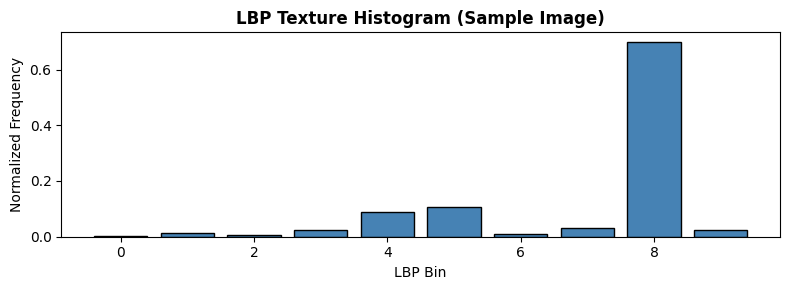

✅ LBP feature vector length: 10


In [7]:
# ============================================================
# CELL 7: Feature 1 — Local Binary Pattern (LBP)
# Purpose: Capture micro-texture patterns of handwriting strokes
#
# LBP works by:
# - For each pixel, compare it with its 8 neighbors
# - Encode result as binary number → build histogram
# - Different writers → different texture histograms
# This is a classical image processing descriptor (Ojala et al., 1996)
# ============================================================

def compute_lbp_features(gray_img, P=8, R=1):
    """
    Compute Local Binary Pattern histogram for texture description.
    P = number of neighbors, R = radius
    Returns a normalized histogram vector.
    """
    lbp = local_binary_pattern(gray_img, P=P, R=R, method='uniform')
    n_bins = P + 2  # uniform LBP bins
    hist, _ = np.histogram(lbp.ravel(), bins=n_bins,
                           range=(0, n_bins), density=True)
    return hist  # length = P+2 = 10

# ---- Demo ----
lbp_demo = compute_lbp_features(gray_test)
plt.figure(figsize=(8, 3))
plt.bar(range(len(lbp_demo)), lbp_demo, color='steelblue', edgecolor='black')
plt.title("LBP Texture Histogram (Sample Image)", fontweight='bold')
plt.xlabel("LBP Bin")
plt.ylabel("Normalized Frequency")
plt.tight_layout()
plt.show()
print(f"✅ LBP feature vector length: {len(lbp_demo)}")

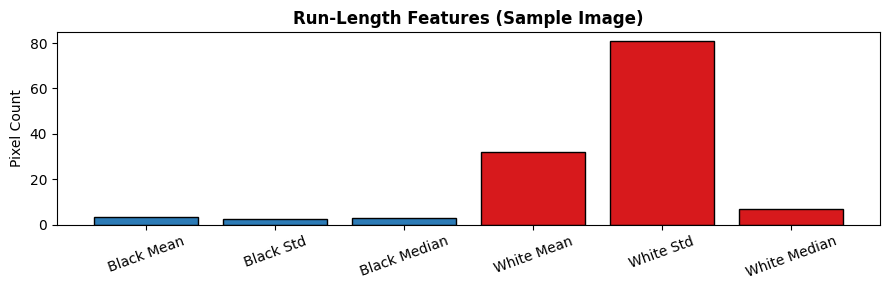

✅ Run-length feature vector length: 6
   Black Mean: 3.50
   Black Std: 2.31
   Black Median: 3.00
   White Mean: 32.09
   White Std: 80.70
   White Median: 7.00


In [8]:
# ============================================================
# CELL 8: Feature 2 — Run-Length Features
# Purpose: Measure stroke thickness and spacing patterns
#
# Run-Length Analysis:
# - Horizontal runs of BLACK pixels → stroke width
# - Horizontal runs of WHITE pixels → inter-stroke spacing
# - Different writers have different stroke thickness habits
# ============================================================

def compute_run_length_features(binary_img):
    """
    Compute run-length statistics from binary image.
    Measures black (ink) and white (space) run statistics.
    Returns a 6-element feature vector.
    """
    # Invert: make ink = 1, background = 0
    ink = (binary_img < 128).astype(np.uint8)

    black_runs = []
    white_runs = []

    for row in ink:
        run_val   = row[0]
        run_len   = 1
        for px in row[1:]:
            if px == run_val:
                run_len += 1
            else:
                if run_val == 1:
                    black_runs.append(run_len)
                else:
                    white_runs.append(run_len)
                run_val = px
                run_len = 1
        # End of row
        if run_val == 1:
            black_runs.append(run_len)
        else:
            white_runs.append(run_len)

    # Compute statistics safely
    def safe_stats(runs):
        if len(runs) == 0:
            return [0.0, 0.0, 0.0]
        arr = np.array(runs, dtype=float)
        return [np.mean(arr), np.std(arr), np.median(arr)]

    features = safe_stats(black_runs) + safe_stats(white_runs)
    return np.array(features)  # length = 6

rl_demo = compute_run_length_features(bin_test)
labels  = ['Black Mean', 'Black Std', 'Black Median',
           'White Mean', 'White Std', 'White Median']
plt.figure(figsize=(9, 3))
bars = plt.bar(labels, rl_demo, color=['#2c7bb6']*3 + ['#d7191c']*3, edgecolor='black')
plt.title("Run-Length Features (Sample Image)", fontweight='bold')
plt.ylabel("Pixel Count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()
print(f"✅ Run-length feature vector length: {len(rl_demo)}")
for l, v in zip(labels, rl_demo):
    print(f"   {l}: {v:.2f}")

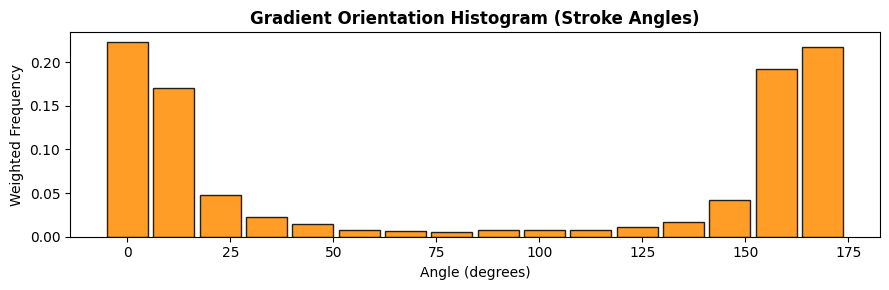

✅ Gradient orientation feature vector length: 16


In [9]:
# ============================================================
# CELL 9: Feature 3 — Gradient Orientation Histogram
# Purpose: Capture pen stroke directions (angle of strokes)
#
# Uses Sobel operators (classical image processing) to find
# gradient direction at each pixel, then builds a histogram
# of dominant stroke angles. Different writers hold pen
# differently → different dominant stroke directions.
# ============================================================

def compute_gradient_orientation_hist(gray_img, n_bins=16):
    """
    Compute histogram of gradient orientations using Sobel filters.
    n_bins = number of angle bins (0° to 180°)
    Returns normalized histogram of stroke angles.
    """
    # Sobel gradients in X and Y
    gx = cv2.Sobel(gray_img.astype(np.float32), cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray_img.astype(np.float32), cv2.CV_32F, 0, 1, ksize=3)

    # Gradient magnitude and angle (0 to 180 degrees)
    magnitude = np.sqrt(gx**2 + gy**2)
    angle     = np.arctan2(np.abs(gy), gx) * (180.0 / np.pi)  # 0-180

    # Only consider pixels with significant gradient (ink edges)
    threshold = magnitude.max() * 0.1
    mask      = magnitude > threshold

    # Weighted histogram: weight each bin by gradient magnitude
    hist, _ = np.histogram(angle[mask], bins=n_bins, range=(0, 180),
                           weights=magnitude[mask])

    # Normalize
    total = hist.sum()
    if total > 0:
        hist = hist / total
    return hist  # length = n_bins = 16

# ---- Demo ----
goh_demo = compute_gradient_orientation_hist(gray_test)
angles   = np.linspace(0, 180, len(goh_demo), endpoint=False)

plt.figure(figsize=(9, 3))
plt.bar(angles, goh_demo, width=10, color='darkorange', edgecolor='black', alpha=0.85)
plt.title("Gradient Orientation Histogram (Stroke Angles)", fontweight='bold')
plt.xlabel("Angle (degrees)")
plt.ylabel("Weighted Frequency")
plt.tight_layout()
plt.show()
print(f"✅ Gradient orientation feature vector length: {len(goh_demo)}")

In [10]:
# ============================================================
# CELL 10: Feature 4 — Slant & Skew Analysis
# Purpose: Measure writing tilt and word spacing patterns
#
# - Slant: how much letters lean left or right
# - Ink density: proportion of black pixels (pen pressure proxy)
# - Row variance: consistency of writing baseline
# ============================================================

def compute_slant_features(binary_img):
    """
    Compute writing slant and structural statistics.
    Returns a 5-element feature vector.
    """
    # Make ink = 1
    ink = (binary_img < 128).astype(np.float32)
    h, w = ink.shape

    # ── Feature 1: Ink Density ──
    ink_density = ink.mean()

    # ── Feature 2: Row-wise ink density variance (baseline regularity) ──
    row_density = ink.mean(axis=1)
    row_variance = np.var(row_density)

    # ── Feature 3: Column-wise ink density variance (spacing regularity) ──
    col_density = ink.mean(axis=0)
    col_variance = np.var(col_density)

    # ── Feature 4 & 5: Slant via projection profile shear ──
    # For each row, find center of mass of ink pixels
    col_indices = np.arange(w, dtype=float)
    centers = []
    for r in range(h):
        row_ink = ink[r]
        s = row_ink.sum()
        if s > 0:
            centers.append(np.dot(row_ink, col_indices) / s)

    if len(centers) > 2:
        # Fit linear trend to center-of-mass positions
        x    = np.arange(len(centers), dtype=float)
        coef = np.polyfit(x, centers, 1)
        slant_slope  = coef[0]   # Positive = right lean, Negative = left lean
        slant_intercept = coef[1]
    else:
        slant_slope     = 0.0
        slant_intercept = 0.0

    return np.array([ink_density, row_variance, col_variance,
                     slant_slope, slant_intercept])  # length = 5

sf_demo = compute_slant_features(bin_test)
labels  = ['Ink Density', 'Row Variance', 'Col Variance',
           'Slant Slope', 'Slant Intercept']
print("✅ Slant & Structural Features:")
for l, v in zip(labels, sf_demo):
    print(f"   {l:20s}: {v:.6f}")
print(f"\n✅ Slant feature vector length: {len(sf_demo)}")

✅ Slant & Structural Features:
   Ink Density         : 0.093704
   Row Variance        : 0.014376
   Col Variance        : 0.006614
   Slant Slope         : -2.660134
   Slant Intercept     : 365.803272

✅ Slant feature vector length: 5


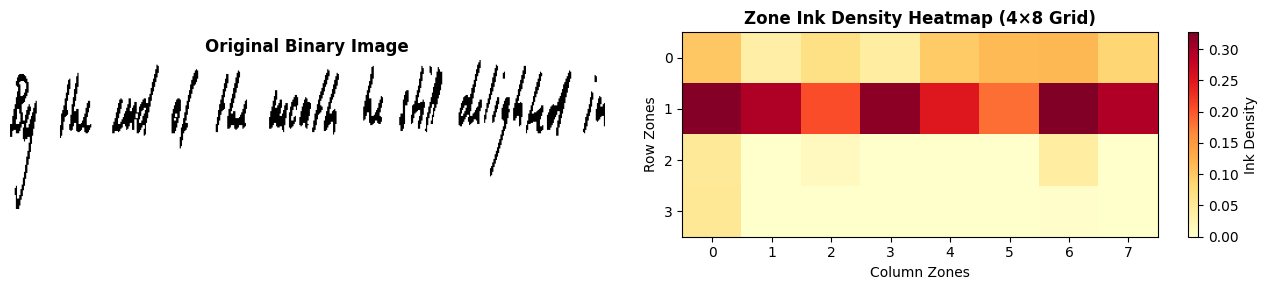

✅ Zone feature vector length: 32


In [11]:
# ============================================================
# CELL 11: Feature 5 — Zone-based Ink Distribution
# Purpose: Analyze where ink appears in different zones of the image
#
# Divides image into a 4x8 grid and computes ink density per zone.
# Captures writing style patterns like uppercase vs lowercase,
# ascender/descender usage, word spacing, margins.
# ============================================================

def compute_zone_features(binary_img, grid_rows=4, grid_cols=8):
    """
    Divide image into a grid and compute ink density per zone.
    Returns a flattened feature vector of length grid_rows * grid_cols.
    """
    ink = (binary_img < 128).astype(np.float32)
    h, w = ink.shape

    zone_features = []
    row_step = h // grid_rows
    col_step = w // grid_cols

    for r in range(grid_rows):
        for c in range(grid_cols):
            r_start = r * row_step
            r_end   = (r + 1) * row_step if r < grid_rows - 1 else h
            c_start = c * col_step
            c_end   = (c + 1) * col_step if c < grid_cols - 1 else w
            zone    = ink[r_start:r_end, c_start:c_end]
            zone_features.append(zone.mean())

    return np.array(zone_features)  # length = 32

zf_demo = compute_zone_features(bin_test)

# Visualize as heatmap
fig, axes = plt.subplots(1, 2, figsize=(13, 3))
axes[0].imshow(bin_test, cmap='gray')
axes[0].set_title("Original Binary Image", fontweight='bold')
axes[0].axis('off')

zone_grid = zf_demo.reshape(4, 8)
im = axes[1].imshow(zone_grid, cmap='YlOrRd', aspect='auto')
axes[1].set_title("Zone Ink Density Heatmap (4×8 Grid)", fontweight='bold')
axes[1].set_xlabel("Column Zones")
axes[1].set_ylabel("Row Zones")
plt.colorbar(im, ax=axes[1], label='Ink Density')
plt.tight_layout()
plt.show()
print(f"✅ Zone feature vector length: {len(zf_demo)}")

In [12]:
# ============================================================
# CELL 12: Combine All Features into One Vector
# Purpose: Merge all 5 feature types into one descriptor per image
#
# Final feature vector breakdown:
# - LBP texture:             10 values
# - Run-length (strokes):     6 values
# - Gradient orientations:   16 values
# - Slant & structure:        5 values
# - Zone distribution:       32 values
# ─────────────────────────────────────
# TOTAL:                     69 values
# ============================================================

def extract_all_features(image_path):
    """
    Full pipeline: load → preprocess → extract all features → concatenate.
    Returns a single 1D feature vector, or None if image fails to load.
    """
    gray, binary = preprocess_image(image_path)
    if gray is None:
        return None

    lbp   = compute_lbp_features(gray)               # 10
    rl    = compute_run_length_features(binary)       #  6
    goh   = compute_gradient_orientation_hist(gray)   # 16
    slant = compute_slant_features(binary)            #  5
    zone  = compute_zone_features(binary)             # 32

    feature_vec = np.concatenate([lbp, rl, goh, slant, zone])

    # Replace any NaN/Inf with 0
    feature_vec = np.nan_to_num(feature_vec, nan=0.0, posinf=0.0, neginf=0.0)
    return feature_vec

# Test it
test_feat = extract_all_features(test_path)
print(f"✅ Feature extraction working!")
print(f"   Total feature vector length: {len(test_feat)}")
print(f"   Feature breakdown: LBP(10) + RunLen(6) + GradOrient(16) + Slant(5) + Zone(32) = 69")

✅ Feature extraction working!
   Total feature vector length: 69
   Feature breakdown: LBP(10) + RunLen(6) + GradOrient(16) + Slant(5) + Zone(32) = 69


In [13]:
# ============================================================
# CELL 13: Extract Features for All Writers
# Purpose: Process all selected writer images and build feature database
# This cell may take 3-8 minutes depending on dataset size
# ============================================================

writer_features = {}   # writer_id → list of feature vectors
writer_profiles = {}   # writer_id → mean feature vector (writer's "signature")

total_images = sum(min(len(files), MAX_PER_WRITER) for _, files in selected_writers)
processed    = 0
failed       = 0

print(f"🔄 Extracting features from {total_images} images across {len(selected_writers)} writers...")
print("─" * 60)

for wid, files in selected_writers:
    feats = []
    use_files = files[:MAX_PER_WRITER]

    for fname in use_files:
        fpath = os.path.join(DATASET_PATH, fname)
        fvec  = extract_all_features(fpath)
        if fvec is not None:
            feats.append(fvec)
            processed += 1
        else:
            failed += 1

    if feats:
        writer_features[wid] = feats
        # Writer profile = mean of all their feature vectors
        writer_profiles[wid] = np.mean(feats, axis=0)
        print(f"   ✅ Writer '{wid}': {len(feats)} images processed")
    else:
        print(f"   ❌ Writer '{wid}': no valid images")

print("─" * 60)
print(f"\n✅ Feature extraction complete!")
print(f"   Total processed : {processed}")
print(f"   Failed/skipped  : {failed}")
print(f"   Writers profiled: {len(writer_profiles)}")

🔄 Extracting features from 150 images across 15 writers...
────────────────────────────────────────────────────────────
   ✅ Writer 'g06': 10 images processed
   ✅ Writer 'c03': 10 images processed
   ✅ Writer 'a01': 10 images processed
   ✅ Writer 'r06': 10 images processed
   ✅ Writer 'a05': 10 images processed
   ✅ Writer 'n06': 10 images processed
   ✅ Writer 'c06': 10 images processed
   ✅ Writer 'b06': 10 images processed
   ✅ Writer 'p06': 10 images processed
   ✅ Writer 'a02': 10 images processed
   ✅ Writer 'm06': 10 images processed
   ✅ Writer 'j06': 10 images processed
   ✅ Writer 'h06': 10 images processed
   ✅ Writer 'd06': 10 images processed
   ✅ Writer 'p03': 10 images processed
────────────────────────────────────────────────────────────

✅ Feature extraction complete!
   Total processed : 150
   Failed/skipped  : 0
   Writers profiled: 15


In [14]:
# ============================================================
# CELL 14: Feature Normalization
# Purpose: Normalize feature vectors so each dimension contributes equally
# Uses Z-score normalization (subtract mean, divide by std)
# ============================================================

# Build a matrix of all writer profiles: shape = (n_writers, 69)
writer_ids_list = list(writer_profiles.keys())
profile_matrix  = np.array([writer_profiles[wid] for wid in writer_ids_list])

# Z-score normalization across writers
feat_mean = profile_matrix.mean(axis=0)
feat_std  = profile_matrix.std(axis=0) + 1e-8  # Avoid division by zero

profile_matrix_norm = (profile_matrix - feat_mean) / feat_std

print(f"✅ Feature normalization complete!")
print(f"   Profile matrix shape: {profile_matrix_norm.shape}")
print(f"   (rows=writers, cols=features)")
print(f"   After normalization — Mean: {profile_matrix_norm.mean():.4f}, Std: {profile_matrix_norm.std():.4f}")

✅ Feature normalization complete!
   Profile matrix shape: (15, 69)
   (rows=writers, cols=features)
   After normalization — Mean: 0.0000, Std: 1.0000


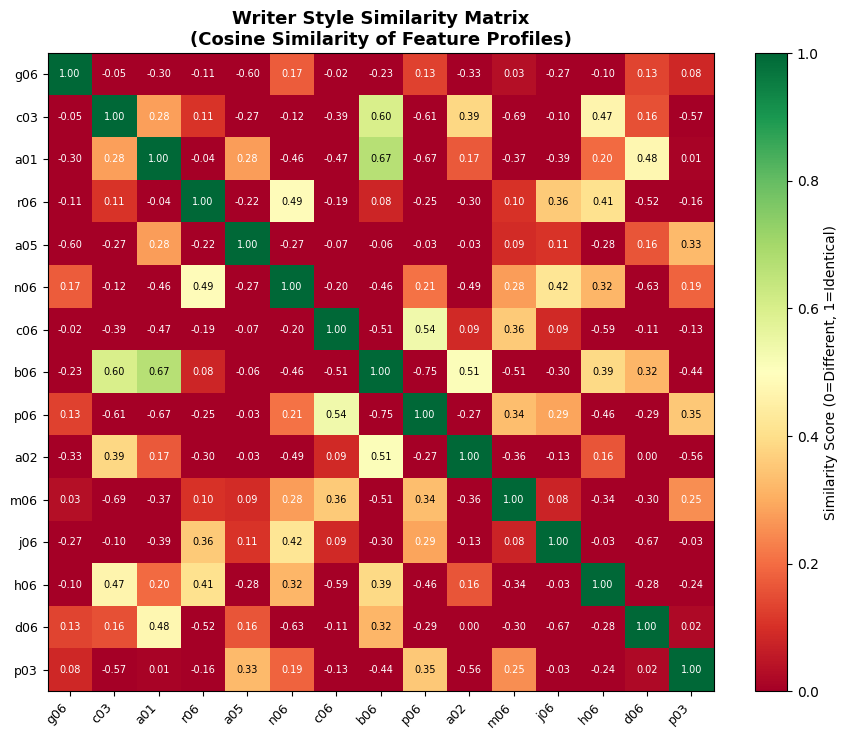

✅ Similarity matrix computed!


In [15]:
# ============================================================
# CELL 15: Cosine Similarity Matrix
# Purpose: Compute pairwise similarity between all writer profiles
#
# Cosine similarity measures the angle between two feature vectors.
# Score = 1.0 → identical writing style
# Score = 0.0 → completely different style
# This is pure mathematics — no ML involved.
# ============================================================

def cosine_similarity_matrix(matrix):
    """
    Compute pairwise cosine similarity between all rows of matrix.
    Returns n×n similarity matrix.
    """
    # L2-normalize each row
    norms    = np.linalg.norm(matrix, axis=1, keepdims=True) + 1e-8
    normed   = matrix / norms
    sim_mat  = normed @ normed.T  # Dot product = cosine similarity for unit vectors
    return sim_mat

sim_matrix = cosine_similarity_matrix(profile_matrix_norm)

# Plot heatmap
n = len(writer_ids_list)
fig, ax = plt.subplots(figsize=(max(8, n*0.6), max(6, n*0.5)))
im = ax.imshow(sim_matrix, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(writer_ids_list, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(writer_ids_list, fontsize=9)
ax.set_title("Writer Style Similarity Matrix\n(Cosine Similarity of Feature Profiles)",
             fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, label='Similarity Score (0=Different, 1=Identical)')

# Add score text in cells
for i in range(n):
    for j in range(n):
        ax.text(j, i, f'{sim_matrix[i,j]:.2f}',
                ha='center', va='center', fontsize=7,
                color='black' if 0.3 < sim_matrix[i,j] < 0.8 else 'white')

plt.tight_layout()
plt.show()
print("✅ Similarity matrix computed!")

In [16]:
# ============================================================
# CELL 16: Writer Identification Function
# Purpose: Given an unknown handwriting image, identify the writer
#
# Method:
# 1. Extract features from the unknown image
# 2. Compare with all known writer profiles using cosine similarity
# 3. Return the writer with highest similarity score
# ============================================================

def identify_writer(image_path, writer_profiles, feat_mean, feat_std,
                    top_k=3, verbose=True):
    """
    Identify the writer of a given handwriting image.

    Args:
        image_path   : path to unknown handwriting image
        writer_profiles : dict of writer_id → mean feature vector
        feat_mean    : feature mean from training set (for normalization)
        feat_std     : feature std from training set
        top_k        : show top-k matches
        verbose      : print results

    Returns:
        best_writer, similarity_scores dict
    """
    # Extract features from query image
    query_feat = extract_all_features(image_path)
    if query_feat is None:
        print("❌ Could not load image!")
        return None, {}

    # Normalize query using training statistics
    query_norm = (query_feat - feat_mean) / feat_std
    query_norm = query_norm / (np.linalg.norm(query_norm) + 1e-8)

    # Compute cosine similarity with each writer profile
    scores = {}
    for wid, profile in writer_profiles.items():
        prof_norm = (profile - feat_mean) / feat_std
        prof_norm = prof_norm / (np.linalg.norm(prof_norm) + 1e-8)
        scores[wid] = float(np.dot(query_norm, prof_norm))

    # Sort by similarity
    sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    best_writer   = sorted_scores[0][0]

    if verbose:
        print(f"\n🔍 Query image: {os.path.basename(image_path)}")
        print(f"\n{'Rank':<6} {'Writer':<12} {'Similarity':>12} {'Bar'}")
        print("─" * 55)
        for rank, (wid, score) in enumerate(sorted_scores[:top_k], 1):
            bar = '█' * int(score * 30)
            marker = ' ← BEST MATCH' if rank == 1 else ''
            print(f"{rank:<6} {wid:<12} {score:>12.4f}  {bar}{marker}")
        print("─" * 55)
        print(f"\n✅ Predicted Writer: '{best_writer}' (similarity = {scores[best_writer]:.4f})")

    return best_writer, scores

print("✅ identify_writer() function defined and ready!")

✅ identify_writer() function defined and ready!


In [17]:
# ============================================================
# CELL 17: Test Writer Identification
# Purpose: Test the system on sample images from the dataset
# Here we pick images from known writers and see if the
# system correctly identifies them
# ============================================================

print("=" * 60)
print("WRITER IDENTIFICATION — TEST RESULTS")
print("=" * 60)

# Test on 3 different writers (use an image NOT used in training if possible)
test_cases = []
for wid, files in selected_writers[:5]:
    # Use the last available image (possibly not in training)
    test_fname = files[-1]
    test_cases.append((wid, test_fname))

correct = 0
total   = len(test_cases)

for true_writer, fname in test_cases:
    fpath = os.path.join(DATASET_PATH, fname)
    predicted, scores = identify_writer(fpath, writer_profiles,
                                        feat_mean, feat_std,
                                        top_k=3, verbose=True)
    match = (predicted == true_writer)
    print(f"   True Writer: '{true_writer}' | Predicted: '{predicted}' | {'✅ CORRECT' if match else '❌ WRONG'}")
    print()
    if match:
        correct += 1

print("=" * 60)
print(f"\n📊 Quick Test Accuracy: {correct}/{total} = {100*correct/total:.1f}%")
print("(Note: For proper accuracy, a held-out test set should be used)")

WRITER IDENTIFICATION — TEST RESULTS

🔍 Query image: g06-115-s01-01.png

Rank   Writer         Similarity Bar
───────────────────────────────────────────────────────
1      h06                0.6924  ████████████████████ ← BEST MATCH
2      n06                0.5750  █████████████████
3      r06                0.5008  ███████████████
───────────────────────────────────────────────────────

✅ Predicted Writer: 'h06' (similarity = 0.6924)
   True Writer: 'g06' | Predicted: 'h06' | ❌ WRONG


🔍 Query image: c03-096f-s02-03.png

Rank   Writer         Similarity Bar
───────────────────────────────────────────────────────
1      c03                0.2743  ████████ ← BEST MATCH
2      g06                0.2239  ██████
3      c06                0.1936  █████
───────────────────────────────────────────────────────

✅ Predicted Writer: 'c03' (similarity = 0.2743)
   True Writer: 'c03' | Predicted: 'c03' | ✅ CORRECT


🔍 Query image: a01-132x-s02-03.png

Rank   Writer         Similarity Bar
───────

In [18]:
# ============================================================
# CELL 18: Full Evaluation — Leave-One-Out Testing
# Purpose: Rigorous accuracy measurement using Leave-One-Out strategy
#
# For each image in each writer's set:
# 1. Build writer profiles WITHOUT that image
# 2. Identify the writer of that image
# 3. Check if it matches the true writer
#
# This is the most honest way to measure accuracy.
# ============================================================

print("🔄 Running Leave-One-Out evaluation...")
print("   (This may take a few minutes)")
print("─" * 50)

total_correct   = 0
total_tested    = 0
per_writer_acc  = {}

for wid, feat_list in writer_features.items():
    if len(feat_list) < 2:
        continue  # Need at least 2 images for LOO

    writer_correct = 0
    n = len(feat_list)

    for i in range(n):
        # Build leave-one-out profiles
        loo_profiles = {}
        for wid2, flist2 in writer_features.items():
            if wid2 == wid:
                # Exclude image i from this writer's profile
                loo_feats = [f for j, f in enumerate(flist2) if j != i]
            else:
                loo_feats = flist2
            if loo_feats:
                loo_profiles[wid2] = np.mean(loo_feats, axis=0)

        # Query: the held-out image
        query = feat_list[i]
        query_norm = (query - feat_mean) / feat_std
        query_norm = query_norm / (np.linalg.norm(query_norm) + 1e-8)

        # Find best match
        best_wid  = None
        best_score = -1
        for wid2, profile in loo_profiles.items():
            prof_norm = (profile - feat_mean) / feat_std
            prof_norm = prof_norm / (np.linalg.norm(prof_norm) + 1e-8)
            score = float(np.dot(query_norm, prof_norm))
            if score > best_score:
                best_score = score
                best_wid   = wid2

        if best_wid == wid:
            writer_correct += 1
            total_correct  += 1
        total_tested += 1

    per_writer_acc[wid] = 100 * writer_correct / n
    print(f"   Writer '{wid}': {writer_correct}/{n} correct ({per_writer_acc[wid]:.0f}%)")

overall_acc = 100 * total_correct / total_tested if total_tested > 0 else 0
print("─" * 50)
print(f"\n✅ Leave-One-Out Accuracy: {total_correct}/{total_tested} = {overall_acc:.1f}%")

🔄 Running Leave-One-Out evaluation...
   (This may take a few minutes)
──────────────────────────────────────────────────
   Writer 'g06': 6/10 correct (60%)
   Writer 'c03': 9/10 correct (90%)
   Writer 'a01': 1/10 correct (10%)
   Writer 'r06': 6/10 correct (60%)
   Writer 'a05': 5/10 correct (50%)
   Writer 'n06': 2/10 correct (20%)
   Writer 'c06': 2/10 correct (20%)
   Writer 'b06': 7/10 correct (70%)
   Writer 'p06': 6/10 correct (60%)
   Writer 'a02': 9/10 correct (90%)
   Writer 'm06': 2/10 correct (20%)
   Writer 'j06': 0/10 correct (0%)
   Writer 'h06': 8/10 correct (80%)
   Writer 'd06': 8/10 correct (80%)
   Writer 'p03': 0/10 correct (0%)
──────────────────────────────────────────────────

✅ Leave-One-Out Accuracy: 71/150 = 47.3%


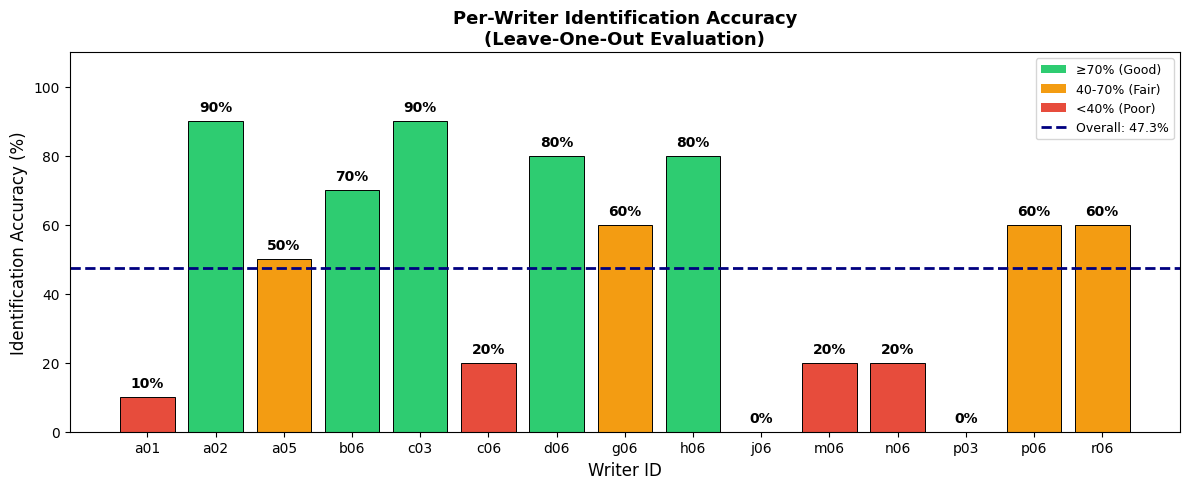

In [19]:
# ============================================================
# CELL 19: Per-Writer Accuracy Bar Chart
# Purpose: Visualize accuracy per writer for the report/presentation
# ============================================================

writers_sorted = sorted(per_writer_acc.keys())
accs = [per_writer_acc[w] for w in writers_sorted]

colors = ['#2ecc71' if a >= 70 else '#f39c12' if a >= 40 else '#e74c3c' for a in accs]

fig, ax = plt.subplots(figsize=(max(10, len(writers_sorted)*0.8), 5))
bars = ax.bar(writers_sorted, accs, color=colors, edgecolor='black', linewidth=0.7)
ax.axhline(overall_acc, color='navy', linestyle='--', linewidth=2,
           label=f'Overall Avg: {overall_acc:.1f}%')
ax.set_xlabel("Writer ID", fontsize=12)
ax.set_ylabel("Identification Accuracy (%)", fontsize=12)
ax.set_title("Per-Writer Identification Accuracy\n(Leave-One-Out Evaluation)",
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 110)
ax.legend(fontsize=11)

# Add value labels on bars
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{acc:.0f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Legend for colors
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='≥70% (Good)'),
                   Patch(facecolor='#f39c12', label='40-70% (Fair)'),
                   Patch(facecolor='#e74c3c', label='<40% (Poor)')]
ax.legend(handles=legend_elements + [plt.Line2D([0],[0],color='navy',
           linestyle='--',lw=2,label=f'Overall: {overall_acc:.1f}%')],
          loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

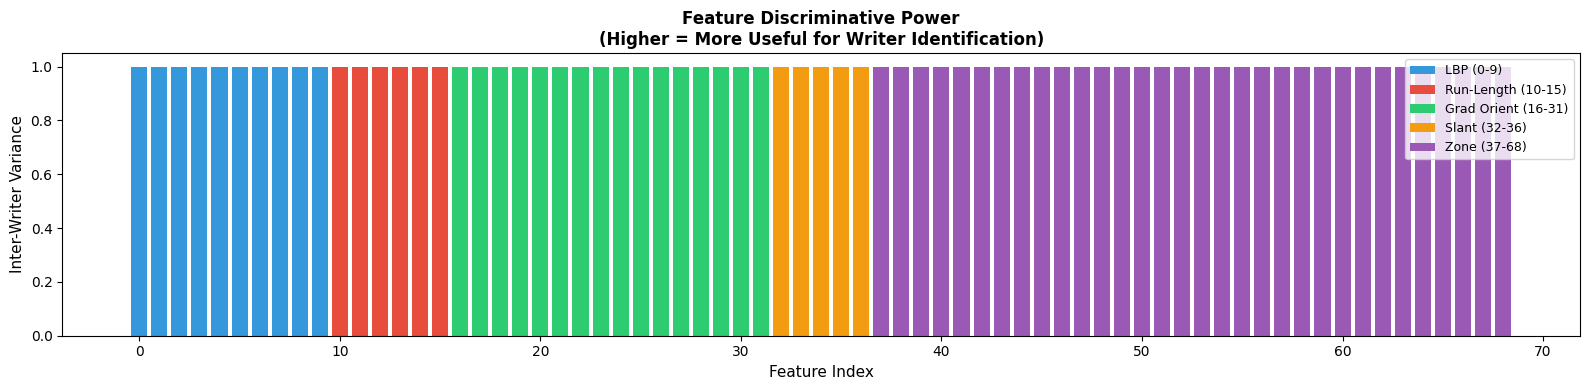


🏆 Top 10 Most Discriminative Features:
Rank  Feature Name         Variance
──────────────────────────────────────
1     Slant_Int              1.0000
2     RL_WhtStd              1.0000
3     RL_WhtMean             1.0000
4     RL_WhtMed              1.0000
5     RL_BlkMean             1.0000
6     RL_BlkMed              1.0000
7     RL_BlkStd              1.0000
8     Slant_Slope            1.0000
9     GOH_0                  1.0000
10    GOH_15                 1.0000


In [20]:
# ============================================================
# CELL 20: Feature Importance Visualization
# Purpose: Show which features differ most between writers
# Uses inter-writer variance as a proxy for discriminative power
# ============================================================

# Compute variance of each feature across writer profiles
feature_variance = np.var(profile_matrix_norm, axis=0)  # shape: (69,)

# Label each feature dimension
feature_labels = (
    [f'LBP_{i}'  for i in range(10)] +
    ['RL_BlkMean','RL_BlkStd','RL_BlkMed','RL_WhtMean','RL_WhtStd','RL_WhtMed'] +
    [f'GOH_{i}'  for i in range(16)] +
    ['Ink_Den','Row_Var','Col_Var','Slant_Slope','Slant_Int'] +
    [f'Zone_{i}' for i in range(32)]
)

fig, ax = plt.subplots(figsize=(16, 4))
x = np.arange(len(feature_variance))

# Color by feature group
group_colors = (['#3498db']*10 + ['#e74c3c']*6 +
                ['#2ecc71']*16 + ['#f39c12']*5 + ['#9b59b6']*32)
ax.bar(x, feature_variance, color=group_colors, edgecolor='none', width=0.8)
ax.set_xlabel("Feature Index", fontsize=11)
ax.set_ylabel("Inter-Writer Variance", fontsize=11)
ax.set_title("Feature Discriminative Power\n(Higher = More Useful for Writer Identification)",
             fontsize=12, fontweight='bold')

legend_elements = [
    Patch(facecolor='#3498db', label='LBP (0-9)'),
    Patch(facecolor='#e74c3c', label='Run-Length (10-15)'),
    Patch(facecolor='#2ecc71', label='Grad Orient (16-31)'),
    Patch(facecolor='#f39c12', label='Slant (32-36)'),
    Patch(facecolor='#9b59b6', label='Zone (37-68)'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

# Print top 10 most discriminative features
top_indices = np.argsort(feature_variance)[::-1][:10]
print("\n🏆 Top 10 Most Discriminative Features:")
print(f"{'Rank':<5} {'Feature Name':<18} {'Variance':>10}")
print("─" * 38)
for rank, idx in enumerate(top_indices, 1):
    print(f"{rank:<5} {feature_labels[idx]:<18} {feature_variance[idx]:>10.4f}")

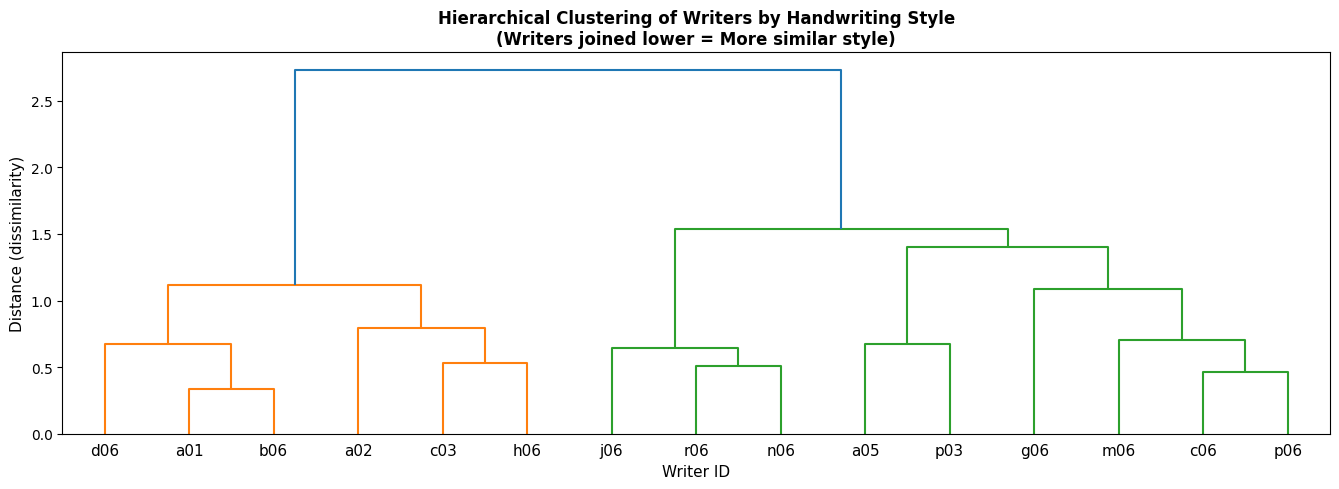

✅ Dendrogram shows style similarity groups among writers.


In [21]:
# ============================================================
# CELL 21: Writer Clustering with Hierarchical Dendrogram
# Purpose: Show which writers have similar handwriting styles
#
# Uses Agglomerative (Hierarchical) Clustering — pure math,
# based on distance calculation only. No ML library used.
# ============================================================

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

# Compute pairwise Euclidean distances between writer profiles
distances = pdist(profile_matrix_norm, metric='cosine')
Z = linkage(distances, method='ward')

fig, ax = plt.subplots(figsize=(max(10, len(writer_ids_list)*0.9), 5))
dendrogram(Z, labels=writer_ids_list, ax=ax,
           color_threshold=0.7 * max(Z[:, 2]),
           leaf_font_size=11)
ax.set_title("Hierarchical Clustering of Writers by Handwriting Style\n"
             "(Writers joined lower = More similar style)",
             fontsize=12, fontweight='bold')
ax.set_xlabel("Writer ID", fontsize=11)
ax.set_ylabel("Distance (dissimilarity)", fontsize=11)
plt.tight_layout()
plt.show()
print("✅ Dendrogram shows style similarity groups among writers.")

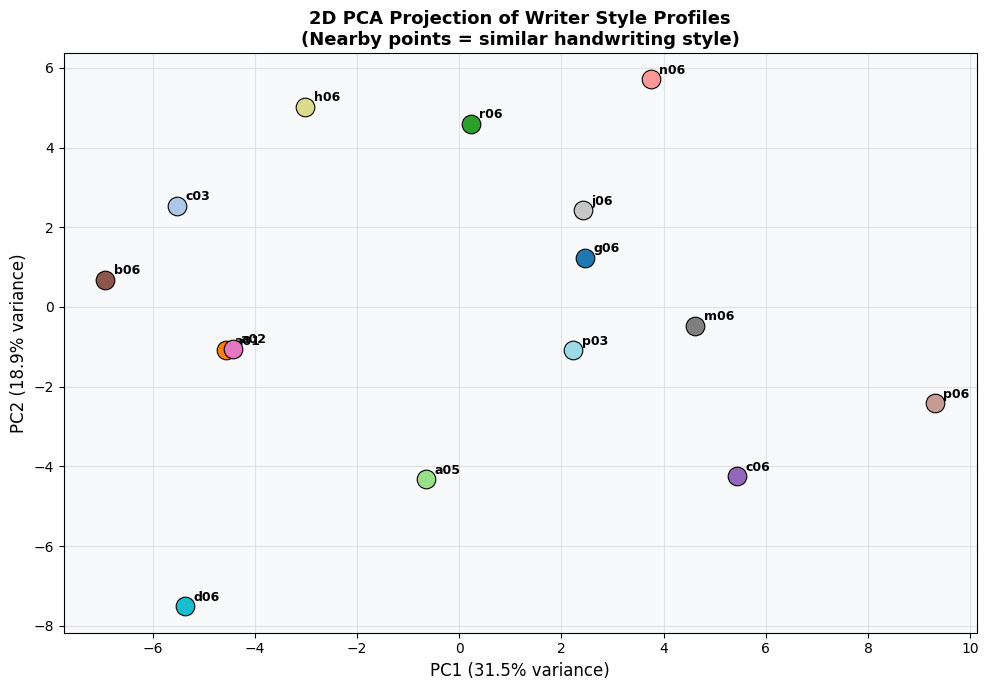

✅ PCA explains 50.4% of total variance in first 2 components


In [22]:
# ============================================================
# CELL 22: 2D PCA Visualization of Writer Styles
# Purpose: Project 69-dim features to 2D for visualization
#
# PCA = Principal Component Analysis
# This is a traditional mathematical dimensionality reduction,
# NOT machine learning. It uses eigenvectors of covariance matrix.
# ============================================================

def manual_pca(matrix, n_components=2):
    """
    Manual PCA using eigenvalue decomposition.
    Pure NumPy — no sklearn or ML library used.
    """
    # Center the data
    centered = matrix - matrix.mean(axis=0)
    # Covariance matrix
    cov_matrix = np.cov(centered.T)
    # Eigendecomposition
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    # Sort by descending eigenvalue
    idx = np.argsort(eigenvalues)[::-1]
    eigenvectors = eigenvectors[:, idx]
    # Project to n_components dimensions
    projected = centered @ eigenvectors[:, :n_components]
    explained = eigenvalues[idx[:n_components]] / eigenvalues.sum()
    return projected, explained

pca_2d, explained_var = manual_pca(profile_matrix_norm, n_components=2)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))
colors_list = plt.cm.tab20(np.linspace(0, 1, len(writer_ids_list)))

for i, wid in enumerate(writer_ids_list):
    ax.scatter(pca_2d[i, 0], pca_2d[i, 1],
               color=colors_list[i], s=180, zorder=5, edgecolor='black', linewidth=0.8)
    ax.annotate(wid, (pca_2d[i, 0], pca_2d[i, 1]),
                fontsize=9, fontweight='bold',
                xytext=(6, 4), textcoords='offset points')

ax.set_xlabel(f"PC1 ({100*explained_var[0]:.1f}% variance)", fontsize=12)
ax.set_ylabel(f"PC2 ({100*explained_var[1]:.1f}% variance)", fontsize=12)
ax.set_title("2D PCA Projection of Writer Style Profiles\n"
             "(Nearby points = similar handwriting style)",
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_facecolor('#f8f9fa')
plt.tight_layout()
plt.show()
print(f"✅ PCA explains {100*sum(explained_var):.1f}% of total variance in first 2 components")

Most similar  writers: 'a01' & 'b06' (score=0.667)
Least similar writers: 'g06' & 'g06' (score=-1.000)


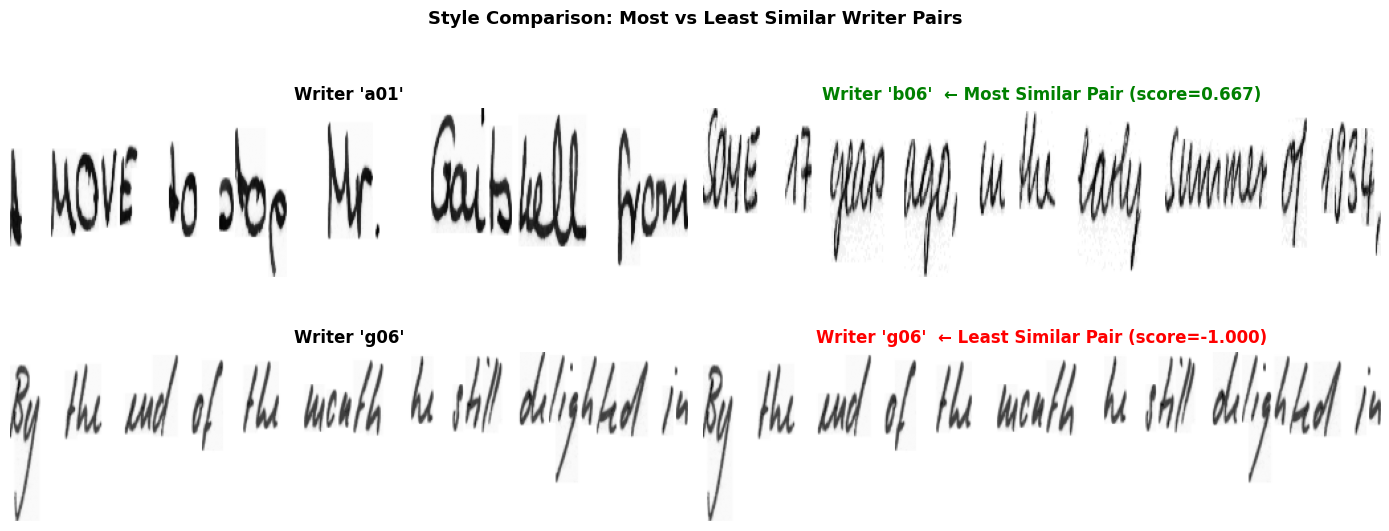

In [23]:
# ============================================================
# CELL 23: Visual Comparison of Two Writers
# Purpose: Show side-by-side comparison of most and least similar writers
# ============================================================

# Find most similar pair (excluding diagonal)
sim_copy = sim_matrix.copy()
np.fill_diagonal(sim_copy, -1)
most_sim_idx  = np.unravel_index(sim_copy.argmax(), sim_copy.shape)
least_sim_idx = np.unravel_index(sim_copy.argmin(), sim_copy.shape)

w_sim1, w_sim2   = writer_ids_list[most_sim_idx[0]],  writer_ids_list[most_sim_idx[1]]
w_diff1, w_diff2 = writer_ids_list[least_sim_idx[0]], writer_ids_list[least_sim_idx[1]]

print(f"Most similar  writers: '{w_sim1}' & '{w_sim2}' (score={sim_copy[most_sim_idx]:.3f})")
print(f"Least similar writers: '{w_diff1}' & '{w_diff2}' (score={sim_copy[least_sim_idx]:.3f})")

def get_sample_image(wid):
    fpath = os.path.join(DATASET_PATH, writer_dict[wid][0])
    img, _ = preprocess_image(fpath)
    return img

fig, axes = plt.subplots(2, 2, figsize=(14, 6))
fig.suptitle("Style Comparison: Most vs Least Similar Writer Pairs",
             fontsize=13, fontweight='bold')

# Most similar
axes[0, 0].imshow(get_sample_image(w_sim1), cmap='gray')
axes[0, 0].set_title(f"Writer '{w_sim1}'", fontweight='bold')
axes[0, 0].axis('off')
axes[0, 1].imshow(get_sample_image(w_sim2), cmap='gray')
axes[0, 1].set_title(f"Writer '{w_sim2}'  ← Most Similar Pair (score={sim_copy[most_sim_idx]:.3f})",
                     fontweight='bold', color='green')
axes[0, 1].axis('off')

# Least similar
axes[1, 0].imshow(get_sample_image(w_diff1), cmap='gray')
axes[1, 0].set_title(f"Writer '{w_diff1}'", fontweight='bold')
axes[1, 0].axis('off')
axes[1, 1].imshow(get_sample_image(w_diff2), cmap='gray')
axes[1, 1].set_title(f"Writer '{w_diff2}'  ← Least Similar Pair (score={sim_copy[least_sim_idx]:.3f})",
                     fontweight='bold', color='red')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

CUSTOM WRITER IDENTIFICATION QUERY


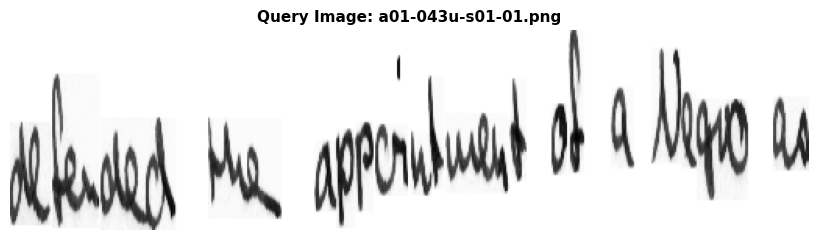


🔍 Query image: a01-043u-s01-01.png

Rank   Writer         Similarity Bar
───────────────────────────────────────────────────────
1      a05                0.6708  ████████████████████ ← BEST MATCH
2      a01                0.4011  ████████████
3      a02                0.2996  ████████
4      b06                0.1866  █████
5      p03                0.1487  ████
───────────────────────────────────────────────────────

✅ Predicted Writer: 'a05' (similarity = 0.6708)


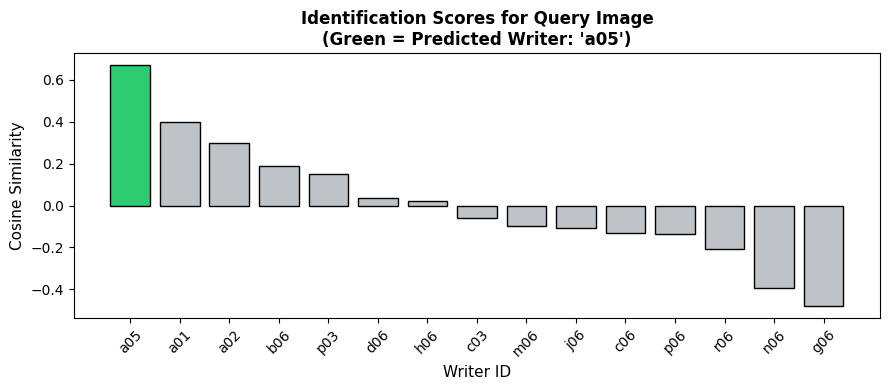

In [24]:
# ============================================================
# CELL 24: Identify a Custom / Unknown Image
# Purpose: Test the system on any image path you specify
#
# ── HOW TO USE ──
# Change QUERY_IMAGE_PATH to any .png image from your dataset
# The system will tell you which known writer it most resembles
# ============================================================

# ── CHANGE THIS TO TEST ANY IMAGE ──
QUERY_IMAGE_PATH = os.path.join(DATASET_PATH, all_images[100])  # Use any image you want!

print("=" * 60)
print("CUSTOM WRITER IDENTIFICATION QUERY")
print("=" * 60)

# Show query image
gray_q, _ = preprocess_image(QUERY_IMAGE_PATH)
if gray_q is not None:
    plt.figure(figsize=(12, 2.5))
    plt.imshow(gray_q, cmap='gray')
    plt.title(f"Query Image: {os.path.basename(QUERY_IMAGE_PATH)}",
              fontsize=11, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Run identification
predicted_writer, all_scores = identify_writer(
    QUERY_IMAGE_PATH, writer_profiles, feat_mean, feat_std,
    top_k=5, verbose=True
)

# Bar chart of scores
sorted_wids   = sorted(all_scores, key=all_scores.get, reverse=True)
sorted_scores = [all_scores[w] for w in sorted_wids]
bar_colors    = ['#2ecc71' if w == predicted_writer else '#bdc3c7' for w in sorted_wids]

plt.figure(figsize=(max(8, len(sorted_wids)*0.6), 4))
plt.bar(sorted_wids, sorted_scores, color=bar_colors, edgecolor='black')
plt.xlabel("Writer ID", fontsize=11)
plt.ylabel("Cosine Similarity", fontsize=11)
plt.title(f"Identification Scores for Query Image\n(Green = Predicted Writer: '{predicted_writer}')",
          fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
# ============================================================
# CELL 25: Final Summary Report
# Purpose: Print complete project summary for submission
# ============================================================

print("╔" + "═"*60 + "╗")
print("║   IVP MINI PROJECT — FINAL SUMMARY REPORT" + " "*16 + "║")
print("║   Handwriting Style Identification (Forensics)" + " "*12 + "║")
print("╠" + "═"*60 + "╣")
print("║ DATASET:" + " "*51 + "║")
print(f"║   Path     : {DATASET_PATH[:46]}" + " "*max(0,46-len(DATASET_PATH[:46])) + "║")
print(f"║   Total images   : {len(all_images):<40} ║")
print(f"║   Writers used   : {len(writer_profiles):<40} ║")
print("╠" + "═"*60 + "╣")
print("║ APPROACH: Traditional Image Processing Only" + " "*16 + "║")
print("║   (No AI / No ML / No DL / No Neural Networks)" + " "*11 + "║")
print("╠" + "═"*60 + "╣")
print("║ FEATURES EXTRACTED:" + " "*40 + "║")
print("║   1. Local Binary Pattern (LBP)     → 10 dims" + " "*12 + "║")
print("║   2. Run-Length Analysis            →  6 dims" + " "*12 + "║")
print("║   3. Gradient Orientation Histogram → 16 dims" + " "*12 + "║")
print("║   4. Slant & Structural Features    →  5 dims" + " "*12 + "║")
print("║   5. Zone Ink Distribution          → 32 dims" + " "*12 + "║")
print(f"║      TOTAL FEATURE VECTOR SIZE      → 69 dims" + " "*12 + "║")
print("╠" + "═"*60 + "╣")
print("║ IDENTIFICATION METHOD:" + " "*37 + "║")
print("║   Cosine Similarity (pure math, no ML)" + " "*21 + "║")
print("╠" + "═"*60 + "╣")
print("║ EVALUATION:" + " "*48 + "║")
print(f"║   Method   : Leave-One-Out Cross Validation" + " "*16 + "║")
print(f"║   Images Tested : {total_tested:<42} ║")
print(f"║   Correct Ident.: {total_correct:<42} ║")
print(f"║   ★ OVERALL ACCURACY: {overall_acc:.1f}%" + " "*max(0,36-len(f'{overall_acc:.1f}')) + "║")
print("╚" + "═"*60 + "╝")

╔════════════════════════════════════════════════════════════╗
║   IVP MINI PROJECT — FINAL SUMMARY REPORT                ║
║   Handwriting Style Identification (Forensics)            ║
╠════════════════════════════════════════════════════════════╣
║ DATASET:                                                   ║
║   Path     : /content/drive/MyDrive/data_subset            ║
║   Total images   : 4899                                     ║
║   Writers used   : 15                                       ║
╠════════════════════════════════════════════════════════════╣
║ APPROACH: Traditional Image Processing Only                ║
║   (No AI / No ML / No DL / No Neural Networks)           ║
╠════════════════════════════════════════════════════════════╣
║ FEATURES EXTRACTED:                                        ║
║   1. Local Binary Pattern (LBP)     → 10 dims            ║
║   2. Run-Length Analysis            →  6 dims            ║
║   3. Gradient Orientation Histogram → 16 dims            ║
║